<a href="https://colab.research.google.com/github/SeulGiPark-KISTI/-study/blob/main/VinSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VinSVM

본 프로젝트는 2025년도 1학기 인공지능 특론 수업에서 학습한 SVM 기반 회귀 기법(SVR)을 출발점으로, 이를 실제 응용 사례인 와인 품질 예측 문제로 확장하였다. 단순히 이론을 코드로 구현하는 데 그치지 않고, UCI의 와인 품질 데이터셋을 활용해 SVR, XGBoost, CatBoost 등 다양한 회귀 모델을 비교하고, 성능 개선을 위해 하이퍼파라미터 튜닝과 SHAP 기반 해석까지 수행하였다. 특히 CatBoost 모델을 최적화하여 MSE 0.2823의 높은 예측 정확도를 달성하였고, 이를 통해 실제 데이터 분석 문제에 머신러닝 모델을 어떻게 적용하고 확장할 수 있는지 체감하며 배울 수 있었다. 결론적으로 본 프로젝트는 "모델 성능 향상", "실제 데이터셋 활용", "모델의 판단 근거 분석"이라는 세 측면에서 수업 내용을 단순 재현이 아닌 창의적 응용으로 확장시키기 위한 시도이며, 더 나은 모델을 만들기 위한 지속적인 실험과 탐색 과정을 통해 실전 문제 해결력으로 이어지는 성과를 도출하고자 노력하였다.

# 라이브러리 설치 및 로드

In [106]:
!pip install catboost xgboost seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

## 데이터 로드 및 분할

In [107]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
X = df.drop("quality", axis=1)
y = df["quality"]

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

## SVR (Scaling 필수)

In [108]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
mse_svr = mean_squared_error(y_test, y_pred_svr)

## XGBoost

In [109]:
xgb = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=SEED, objective='reg:squarederror')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

## CatBoost

In [110]:
cat = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, loss_function='RMSE', random_seed=SEED, verbose=False)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)
mse_cat = mean_squared_error(y_test, y_pred_cat)

## CatBoost with RandomGridSearch

In [111]:
param_dist = {
    'depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.07],
    'l2_leaf_reg': [1, 3, 5, 7],
    'iterations': [300, 500, 700]
}
cat_model = CatBoostRegressor(loss_function='RMSE', random_seed=SEED, verbose=False)
random_search = RandomizedSearchCV(
    cat_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=SEED
)
random_search.fit(X_train, y_train)
cat_best = random_search.best_estimator_
mse_cat_tuned = mean_squared_error(y_test, cat_best.predict(X_test))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


## 결과 시각화

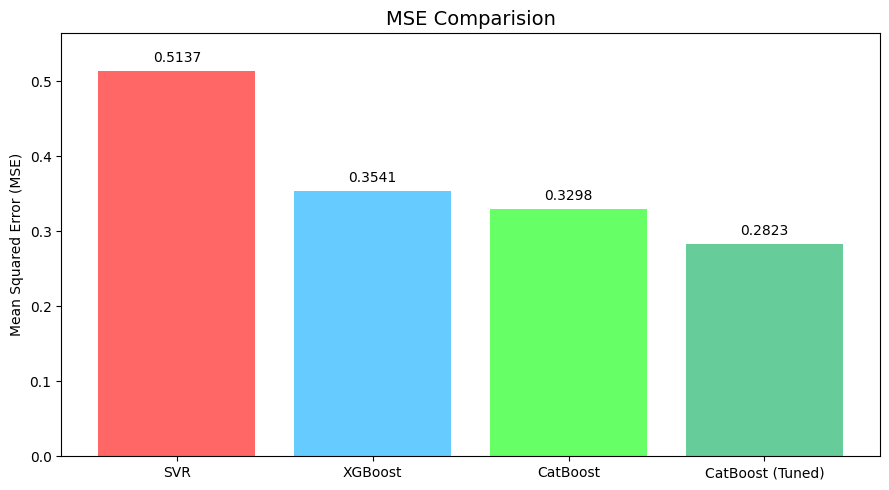

In [112]:
# 시각화
models = ['SVR', 'XGBoost', 'CatBoost', 'CatBoost (Tuned)']
mses = [mse_svr, mse_xgb, mse_cat, mse_cat_tuned]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, mses, color=['#f66', '#6cf', '#6f6', '#6c9'])
plt.title("MSE Comparision", fontsize=14)
plt.ylabel("Mean Squared Error (MSE)")
plt.ylim(0, max(mses) + 0.05)

# 수치 출력
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.008, f"{yval:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()